# Exploration Géospatiale — Digital Twin Düsseldorf
## Use Case 5 : WärmeWegWeiser Auto-Fill

**Objectifs de ce notebook :**
- Charger le dataset et le convertir en GeoDataFrame
- Comprendre et manipuler les données géospatiales (polygones)
- Visualiser les bâtiments sur une carte interactive
- Calculer des features géométriques dérivées
- Tester le pipeline de géocodage (adresse → bâtiment)

## 1. Chargement des données

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point
import matplotlib.pyplot as plt
import folium
from geopy.geocoders import Nominatim
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Chargement du dataset
df = pd.read_csv(r'C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\data\Raw\Gelsenkirchen\Gelsenkirchen_digital_twin_geo_area_aggregated.csv', sep=';')

print(f"Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\nColonnes : {list(df.columns)}")
df.head(3)

Dataset : 1723 lignes, 50 colonnes

Colonnes : ['floor_area_id', 'floor_area_name', 'building_count', 'heated_space', 'floor_area', 'construction_year', 'number_of_apartments_min', 'solar_potential', 'number_of_apartments_max', 'initial_heat_demand', 'construction_year_class__1860 - 1918', 'construction_year_class__1919 - 1948', 'construction_year_class__1949 - 1978', 'construction_year_class__1979 - 1986', 'construction_year_class__1987 - 1990', 'construction_year_class__1991 - 1995', 'construction_year_class__1996 - 2000', 'construction_year_class__2001 - 2004', 'construction_year_class__2005 - 2008', 'construction_year_class__2009 - 2011', 'construction_year_class__2012 - 2023', 'building_type__EFH', 'building_type__GHD', 'building_type__GMH', 'building_type__HH', 'building_type__Industrie', 'building_type__MFH', 'building_type__RH', 'building_type__Öffentlich', 'type_of_use__Gewerbegebäude', 'type_of_use__Industriegebäude', 'type_of_use__Wohngebäude', 'type_of_use__Öffentliche Hand

,floor_area_id,floor_area_name,building_count,heated_space,floor_area,construction_year,number_of_apartments_min,solar_potential,number_of_apartments_max,initial_heat_demand,...,initial_heating_system__Industrie Ölanlage,initial_heating_system__Nachtspeicher (Bestand),initial_heating_system__Nahwärme,initial_heating_system__Pelletkessel (Bestand),initial_heating_system__el. WP (Bestand),initial_heating_system__Ölkessel (Bestand),renovation_state__not_renovated,renovation_state__partially_renovated,renovation_state__renovated,geometry
0,001dd6c2-bd2e-4d03-922f-c0b2d2914772,1088,68,373.039575,189.196175,1953.647059,4.397059,0.0,7.352941,54839.864469,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.470588,0.264706,0.264706,MULTIPOLYGON (((7.050799642906248 51.598575630...
1,007bbfdc-def4-4c63-9e17-ef2566e98a9b,830,53,313.764924,175.756018,1963.792453,4.113208,0.0,7.037736,37008.869989,...,0.0,0.000000,0.0,0.0,0.056604,0.150943,0.245283,0.471698,0.283019,MULTIPOLYGON (((7.035777315071928 51.579419724...
2,00d2543b-741c-403f-867c-e01131753b5b,1749,65,164.922464,95.811572,1972.246154,2.261538,0.0,3.492308,22981.148118,...,0.0,0.061538,0.0,0.0,0.015385,0.015385,0.246154,0.507692,0.246154,MULTIPOLYGON (((7.126287378215317 51.505216161...


In [4]:
# Aperçu rapide des types et valeurs manquantes
print("Types et valeurs manquantes :")
print(pd.DataFrame({
    'type': df.dtypes,
    'non_null': df.notnull().sum(),
    'null': df.isnull().sum(),
    'unique': df.nunique()
}).to_string())

# La colonne data_quality — qu'est-ce qu'elle contient ?
print(f"\ndata_quality — valeurs uniques : {df['floor_area'].unique()}")

Types et valeurs manquantes :
                                                    type  non_null  null  unique
floor_area_id                                        str      1723     0    1723
floor_area_name                                    int64      1723     0    1723
building_count                                     int64      1723     0     106
heated_space                                     float64      1723     0    1723
floor_area                                       float64      1723     0    1723
construction_year                                float64      1723     0    1536
number_of_apartments_min                         float64      1723     0    1006
solar_potential                                  float64      1723     0       1
number_of_apartments_max                         float64      1723     0    1109
initial_heat_demand                              float64      1723     0    1711
construction_year_class__1860 - 1918             float64      1723     0     38

## 2. Conversion en GeoDataFrame

La colonne `geometry` contient des polygones en format WKT (Well-Known Text).  
On les convertit en objets géométriques Shapely pour pouvoir les manipuler.

In [5]:
# Regarder à quoi ressemble une géométrie brute
print("Exemple de géométrie brute :")
print(df['geometry'].iloc[0][:200], "...")

Exemple de géométrie brute :
MULTIPOLYGON (((7.050799642906248 51.5985756305925, 7.050691894991694 51.59883771718796, 7.050683261887915 51.59885871216399, 7.050645118716657 51.59895262123939, 7.05063111410308 51.59898709885591, 7 ...


In [6]:
# Conversion sécurisée — on parse chaque géométrie individuellement
def safe_wkt_load(geom_str):
    """Essaie de parser le WKT, retourne None si ça échoue"""
    try:
        return wkt.loads(geom_str)
    except Exception:
        return None

df_clean = df[df['geometry'].notna() & (df['geometry'] != '')].copy()
df_clean['geometry'] = df_clean['geometry'].apply(safe_wkt_load)

# Identifier les lignes qui ont échoué
failed = df_clean['geometry'].isna()
print(f"Géométries parsées avec succès : {(~failed).sum()} / {len(df_clean)}")
print(f"Géométries qui ont échoué : {failed.sum()}")

if failed.sum() > 0:
    print("\nLignes problématiques :")
    for idx in df_clean[failed].index:
        raw = df.loc[idx, 'geometry']
        print(f"  Ligne {idx} : '{str(raw)[:80]}...'")

# Garder uniquement les lignes valides
df_clean = df_clean[~failed]

# Créer le GeoDataFrame
gdf = gpd.GeoDataFrame(df_clean, geometry='geometry', crs='EPSG:4326')

print(f"\nGeoDataFrame créé : {len(gdf)} bloc de bâtiments")
print(f"Types de géométrie : {gdf.geometry.geom_type.unique()}")

# Vérifier la validité
invalid = (~gdf.is_valid).sum()
print(f"Géométries invalides : {invalid}")
if invalid > 0:
    gdf.loc[~gdf.is_valid, 'geometry'] = gdf.loc[~gdf.is_valid, 'geometry'].buffer(0)

Géométries parsées avec succès : 1723 / 1723
Géométries qui ont échoué : 0

GeoDataFrame créé : 1723 bloc de bâtiments
Types de géométrie : <StringArray>
['MultiPolygon']
Length: 1, dtype: str
Géométries invalides : 0


## 3. Explorer un bâtiment individuellement

Regardons de près ce qu'on peut extraire d'un seul polygone.

In [7]:
# Prendre un bâtiment au hasard
sample = gdf.iloc[17]

print(f"Nombre de batiments dans le bloc : {sample['building_count']}")
print(f"Répartition en pourcentage du type de batiments : {sample['building_type__EFH']}" * 100 , {sample['building_type__GHD']} * 100)
print(f"Type de géométrie : {sample.geometry.geom_type}")

# Extraire les coordonnées du polygone
if sample.geometry.geom_type == 'MultiPolygon':
    polygon = list(sample.geometry.geoms)[0]  # Premier polygone
else:
    polygon = sample.geometry

coords = list(polygon.exterior.coords)
print(f"Nombre de points du contour : {len(coords)}")
print(f"Coordonnées (lon, lat) :")
for i, (lon, lat) in enumerate(coords):
    print(f"  Point {i} : ({lon:.6f}, {lat:.6f})")

# Centroïde
centroid = sample.geometry.centroid
print(f"\nCentroïde : ({centroid.x:.6f}, {centroid.y:.6f})")

# Bounds (rectangle englobant)
print(f"Bounding box : {sample.geometry.bounds}")

Nombre de batiments dans le bloc : 13


TypeError: unsupported operand type(s) for *: 'set' and 'int'

NameError: name 'centroid' is not defined

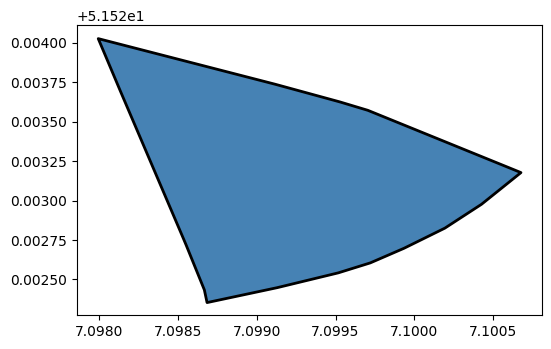

In [8]:
# Visualiser ce bâtiment seul
fig, ax = plt.subplots(figsize=(6, 6))
gpd.GeoSeries([sample.geometry]).plot(ax=ax, color='steelblue', 
                                      edgecolor='black', linewidth=2)
ax.plot(centroid.x, centroid.y, 'ro', markersize=8, label='Centroïde')
ax.set_title(f"{sample['street']} — {sample['building_type']}")
ax.legend()
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 4. Features géométriques dérivées

On calcule des métriques à partir des polygones qui pourront servir de features ML :
- **Surface du polygone** (m²) — à comparer avec `floor_area`
- **Périmètre** (m)
- **Compacité** = 4π × aire / périmètre² (1 = cercle, < 1 = allongé)
- **Aspect ratio** du bounding box (1 = carré, < 1 = rectangulaire)

On projette d'abord en UTM zone 32N (EPSG:25832) pour travailler en mètres.

In [9]:
# Projeter en UTM zone 32N pour calculer en mètres
gdf_proj = gdf.to_crs('EPSG:25832')

# Surface du polygone en m²
gdf['polygon_area_m2'] = gdf_proj.geometry.area

# Périmètre en m
gdf['perimeter_m'] = gdf_proj.geometry.length

# Compacité (4π × aire / périmètre²)
gdf['compactness'] = (4 * np.pi * gdf['polygon_area_m2']) / (gdf['perimeter_m'] ** 2)

# Aspect ratio du bounding box
def aspect_ratio(geom):
    b = geom.bounds  # (minx, miny, maxx, maxy)
    w, h = b[2] - b[0], b[3] - b[1]
    return min(w, h) / max(w, h) if max(w, h) > 0 else 1.0

gdf['aspect_ratio'] = gdf_proj.geometry.apply(aspect_ratio)

# Centroïdes (en WGS84 pour la carte)
gdf['centroid_lon'] = gdf.geometry.centroid.x
gdf['centroid_lat'] = gdf.geometry.centroid.y

print("Features géométriques calculées :")
print(gdf[['polygon_area_m2', 'perimeter_m', 'compactness', 'aspect_ratio']].describe().round(2))

Features géométriques calculées :
       polygon_area_m2  perimeter_m  compactness  aspect_ratio
count          1723.00      1723.00      1723.00       1723.00
mean          51261.72       915.11         0.62          0.74
std           91655.44       585.88         0.14          0.18
min            1309.36       151.90         0.12          0.15
25%           16693.83       563.69         0.54          0.61
50%           26437.49       749.92         0.65          0.77
75%           46811.89      1041.78         0.73          0.89
max         1428627.91      5889.56         0.84          1.00


floor_area — exemple brut : '189.19617467647285'
floor_area — après nettoyage : '18919617467647285'
floor_area — type: int64, NaN: 0

heated_space — exemple brut : '373.0395745377629'
heated_space — après nettoyage : '3730395745377629'
heated_space — type: int64, NaN: 0

initial_heat_demand — exemple brut : '54839.86446883974'
initial_heat_demand — après nettoyage : '5483986446883974'
initial_heat_demand — type: int64, NaN: 0

floor_area_m2 :
count    1723.0
mean     1057.6
std       932.5
min         0.2
25%       218.7
50%       949.0
75%      1583.1
max      6359.5
Name: floor_area_m2, dtype: float64

heated_space_m2 :
count    1723.0
mean     1085.8
std      1119.0
min         0.4
25%       276.3
50%       535.9
75%      1644.1
max      5575.4
Name: heated_space_m2, dtype: float64


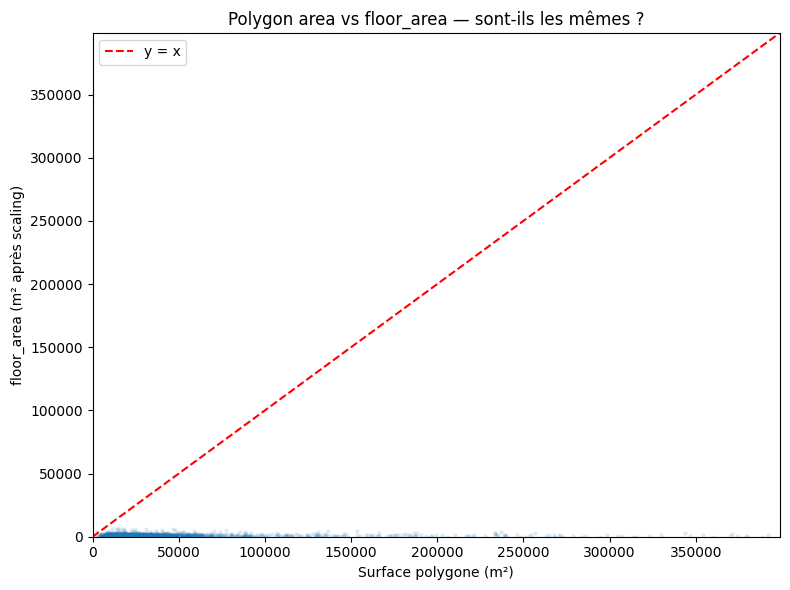


Corrélation polygon_area vs floor_area : -0.0292
(Si très proche de 1.0, floor_area est bien dérivée du polygone)


In [10]:
# Comparer polygon_area_m2 avec floor_area
# D'abord, appliquer le scaling sur floor_area et heated_space
# Exemple : '2.327.713.659.904.320' → 2327713659904320

# Repartir des données brutes du CSV original
for col in ['floor_area', 'heated_space', 'initial_heat_demand']:
    # Reprendre la valeur originale depuis df_clean (avant toute modif)
    raw = df_clean[col].astype(str)
    print(f"{col} — exemple brut : '{raw.iloc[0]}'")
    
    # Supprimer les points (séparateurs de milliers allemands)
    cleaned = raw.str.replace('.', '', regex=False)
    # Supprimer les espaces éventuels
    cleaned = cleaned.str.replace(' ', '', regex=False)
    
    print(f"{col} — après nettoyage : '{cleaned.iloc[0]}'")
    
    gdf[col] = pd.to_numeric(cleaned, errors='coerce')
    print(f"{col} — type: {gdf[col].dtype}, NaN: {gdf[col].isna().sum()}\n")

SCALING_FACTOR = 1e13  

gdf['floor_area_m2'] = gdf['floor_area'] / SCALING_FACTOR
gdf['heated_space_m2'] = gdf['heated_space'] / SCALING_FACTOR

print("floor_area_m2 :")
print(gdf['floor_area_m2'].describe().round(1))
print(f"\nheated_space_m2 :")
print(gdf['heated_space_m2'].describe().round(1))

# Scatter : polygon_area vs floor_area
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(gdf['polygon_area_m2'], gdf['floor_area_m2'], alpha=0.1, s=5)
max_val = max(gdf['polygon_area_m2'].quantile(0.99), gdf['floor_area_m2'].quantile(0.99))
ax.plot([0, max_val], [0, max_val], 'r--', label='y = x')
ax.set_xlabel('Surface polygone (m²)')
ax.set_ylabel('floor_area (m² après scaling)')
ax.set_title('Polygon area vs floor_area — sont-ils les mêmes ?')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.legend()
plt.tight_layout()
plt.show()

corr = gdf['polygon_area_m2'].corr(gdf['floor_area_m2'])
print(f"\nCorrélation polygon_area vs floor_area : {corr:.4f}")
print("(Si très proche de 1.0, floor_area est bien dérivée du polygone)")

In [11]:
# Ratio heated_space / floor_area = proxy du nombre d'étages chauffés
gdf['hs_fa_ratio'] = gdf['heated_space_m2'] / gdf['floor_area_m2']

print("Ratio heated_space / floor_area par type de bâtiment :")
print("(Ce ratio est un proxy du nombre d'étages chauffés)\n")
print(gdf.groupby('building_type')['hs_fa_ratio'].describe().round(2))

Ratio heated_space / floor_area par type de bâtiment :
(Ce ratio est un proxy du nombre d'étages chauffés)



KeyError: 'building_type'

## 5. Visualisation sur carte

### 5a. Carte statique — tous les bâtiments par type

KeyError: 'building_type'

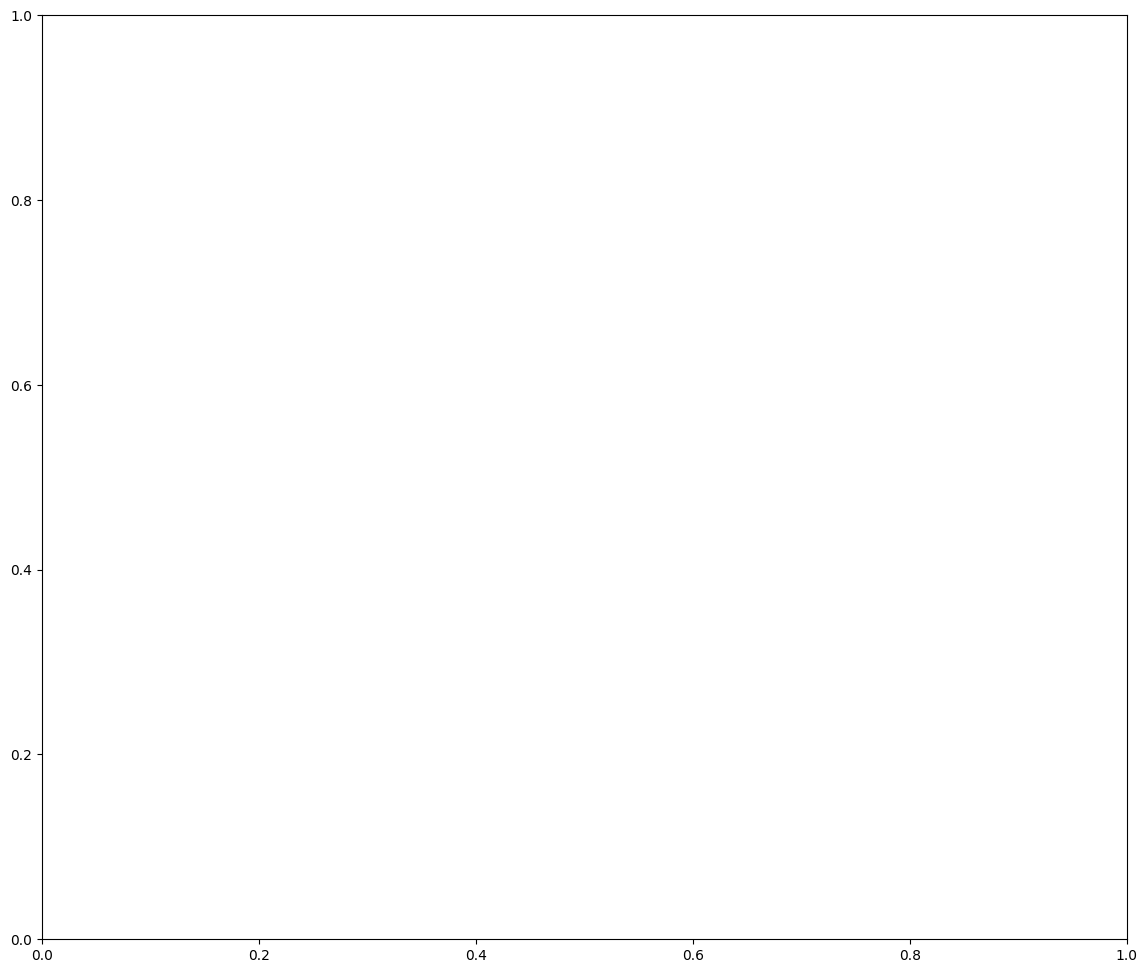

In [12]:
# Carte statique colorée par type de bâtiment
fig, ax = plt.subplots(figsize=(14, 12))

color_map = {
    'EFH': '#2196F3', 'MFH': '#FF9800', 'RH': '#4CAF50',
    'GMH': '#F44336', 'HH': '#9C27B0', 'GHD': '#795548',
    'Öffentlich': '#607D8B', 'Industrie': '#000000'
}

for btype, color in color_map.items():
    subset = gdf[gdf['building_type'] == btype]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='none', alpha=0.6, label=btype)

ax.legend(title='Type de bâtiment', loc='upper right')
ax.set_title(f'Düsseldorf — {len(gdf)} bâtiments par type', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

### 5b. Carte interactive Folium — zoom sur un quartier

On prend un échantillon pour que la carte reste fluide (~500 bâtiments).

In [13]:
# Échantillon pour la carte interactive (Folium rame avec 96K polygones)
sample_size = 1000
gdf_sample = gdf.sample(n=min(sample_size, len(gdf)), random_state=42)

# Centre de la carte
center_lat = gdf_sample['centroid_lat'].mean()
center_lon = gdf_sample['centroid_lon'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=13,
               tiles='CartoDB positron')

for _, row in gdf_sample.iterrows():
    color = color_map.get(row['building_type'], '#999999')
    
    popup_html = (
        f"<b>{row['street']}</b><br>"
        f"Type: {row['building_type']}<br>"
        f"Construction: {row['construction_year']} ({row['construction_year_class']})<br>"
        f"Chauffage: {row['initial_heating_system']}<br>"
        f"Rénovation: {row['renovation_state']}<br>"
        f"Floor area: {row['floor_area_m2']:.1f} m²<br>"
        f"Heated space: {row['heated_space_m2']:.1f} m²<br>"
        f"Ratio HS/FA: {row['hs_fa_ratio']:.2f}<br>"
        f"Heat demand: {row['initial_heat_demand']} kWh/an"
    )
    
    # Extraire les coordonnées de chaque polygone
    if row.geometry.geom_type == 'MultiPolygon':
        polys = list(row.geometry.geoms)
    else:
        polys = [row.geometry]
    
    for poly in polys:
        coords = [(lat, lon) for lon, lat in poly.exterior.coords]
        folium.Polygon(
            locations=coords,
            color=color, fill=True, fill_color=color,
            fill_opacity=0.6, weight=1,
            popup=folium.Popup(popup_html, max_width=300)
        ).add_to(m)

# Afficher la carte dans le notebook
m

### 5c. Carte thématique — heat demand

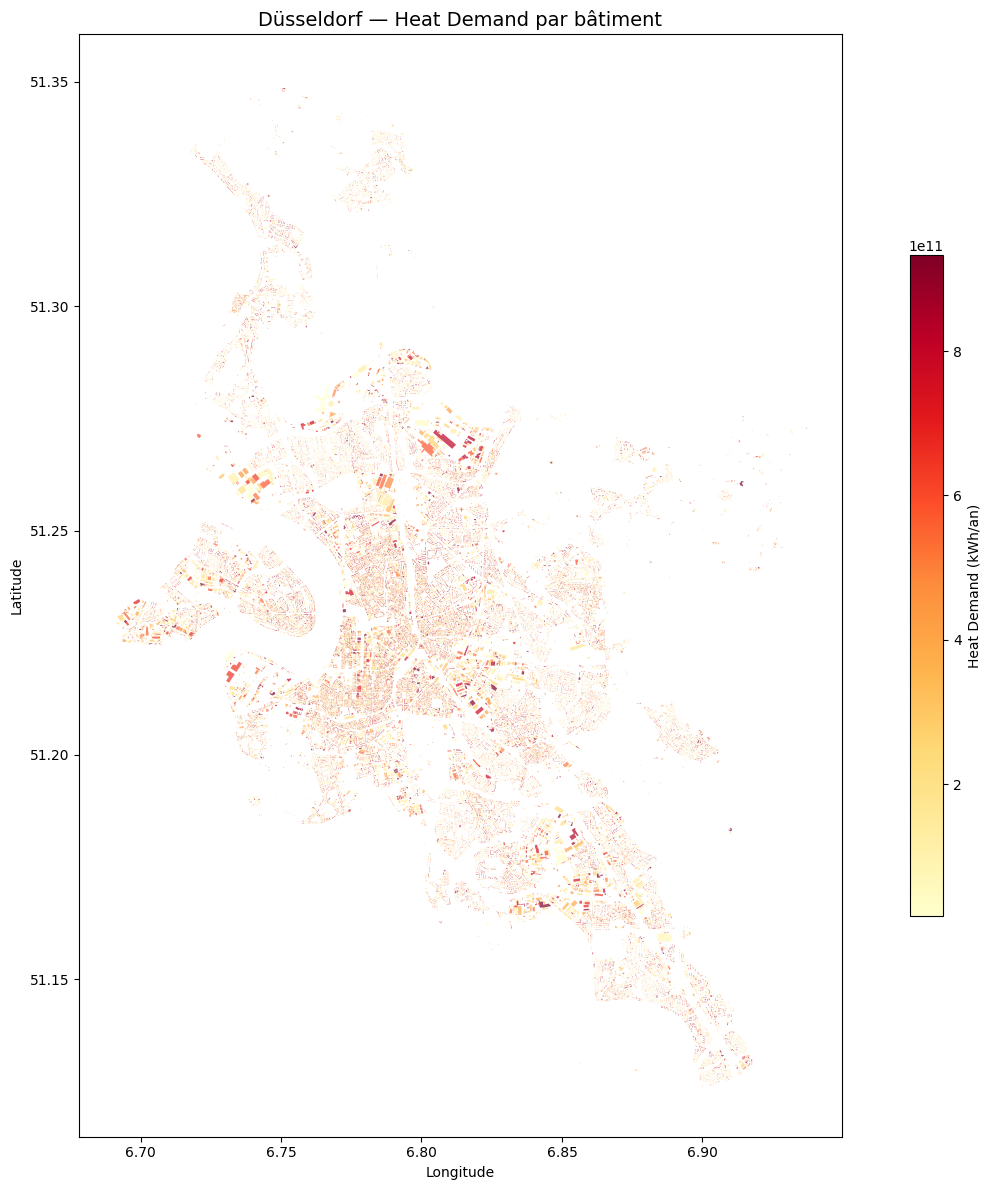

In [14]:
# Carte colorée par initial_heat_demand
fig, ax = plt.subplots(figsize=(14, 12))

gdf.plot(column='initial_heat_demand', ax=ax, legend=True,
         legend_kwds={'label': 'Heat Demand (kWh/an)', 'shrink': 0.6},
         cmap='YlOrRd', edgecolor='none', alpha=0.7,
         vmin=gdf['initial_heat_demand'].quantile(0.05),
         vmax=gdf['initial_heat_demand'].quantile(0.95))

ax.set_title('Düsseldorf — Heat Demand par bâtiment', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 6. Pipeline de géocodage

Test du flow : **adresse → coordonnées GPS → matching spatial → données du bâtiment**

In [15]:
def geocode_address(address):
    """Géocode une adresse → coordonnées GPS"""
    geolocator = Nominatim(user_agent="warmewegweiser_prototype")
    location = geolocator.geocode(address)
    if location:
        print(f"Adresse trouvée : {location.address}")
        print(f"Coordonnées : ({location.latitude:.6f}, {location.longitude:.6f})")
        return Point(location.longitude, location.latitude)
    else:
        print(f"Adresse non trouvée : {address}")
        return None


def find_building(point, buildings_gdf, max_distance_m=50):
    """Trouve le bâtiment correspondant à un point GPS"""
    if point is None:
        return None
    
    point_gdf = gpd.GeoDataFrame(geometry=[point], crs='EPSG:4326')
    
    # Renommer la colonne index_right du dataset pour éviter le conflit avec sjoin
    bdf = buildings_gdf.rename(columns={'index_right': 'index_right_orig'})
    
    # 1. Match exact : le point tombe dans un polygone ?
    matches = gpd.sjoin(point_gdf, bdf, predicate='within')
    if len(matches) > 0:
        idx = matches['index_right'].iloc[0]
        print(f"Match exact ! → {bdf.loc[idx, 'street']}")
        return buildings_gdf.loc[idx]
    
    # 2. Sinon : bâtiment le plus proche
    print("Pas de match exact, recherche du plus proche...")
    point_proj = point_gdf.to_crs('EPSG:25832')
    buildings_proj = bdf.to_crs('EPSG:25832')
    distances = buildings_proj.geometry.distance(point_proj.geometry.iloc[0])
    nearest_idx = distances.idxmin()
    min_dist = distances.min()
    
    if min_dist <= max_distance_m:
        print(f"Plus proche : {buildings_gdf.loc[nearest_idx, 'street']} ({min_dist:.1f} m)")
        return buildings_gdf.loc[nearest_idx]
    else:
        print(f"Trop loin : {min_dist:.1f} m (max = {max_distance_m} m)")
        return None

In [17]:
# --- TEST : Prendre une adresse du dataset et vérifier le matching ---

# On prend une vraie adresse du dataset
test_street = gdf.iloc[17]['street']
test_address = f"{test_street}, Düsseldorf, Germany"
print(f"Test avec : {test_address}\n")

# Étape 1 : Géocodage
point = geocode_address(test_address)


# Étape 2 : Matching
if point:
    result = find_building(point, gdf)
    
    if result is not None:
        print(f"\n{'='*50}")
        print(f"AUTO-FILL WärmeWegWeiser")
        print(f"{'='*50}")
        print(f"Adresse          : {result['street']}")
        print(f"Type             : {result['building_type']}")
        print(f"Construction     : {result['construction_year_class']}")
        print(f"Chauffage        : {result['initial_heating_system']}")
        print(f"Rénovation       : {result['renovation_state']}")
        print(f"Heated space     : {result['heated_space_m2']:.1f} m²")
        print(f"Heat demand      : {result['initial_heat_demand']} kWh/an")

Test avec : Dietrich-Bonhoeffer-Straße 1d, Düsseldorf, Germany

Adresse trouvée : 1d, Dietrich-Bonhoeffer-Straße, Hellerhof, Stadtbezirk 10, Düsseldorf, Nordrhein-Westfalen, 40595, Deutschland
Coordonnées : (51.126392, 6.903943)
Match exact ! → Dietrich-Bonhoeffer-Straße 1d

AUTO-FILL WärmeWegWeiser
Adresse          : Dietrich-Bonhoeffer-Straße 1d
Type             : MFH
Construction     : 1949 - 1978
Chauffage        : Gaskessel (Bestand)
Rénovation       : partially_renovated
Heated space     : 207.4 m²
Heat demand      : 785214686629 kWh/an


In [18]:
# Visualiser le résultat du matching sur la carte
if point and result is not None:
    m2 = folium.Map(location=[point.y, point.x], zoom_start=18,
                    tiles='CartoDB positron')
    
    # Le point géocodé
    folium.Marker(
        location=[point.y, point.x],
        popup=f"Point géocodé : {test_address}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(m2)
    
    # Le bâtiment trouvé
    if result.geometry.geom_type == 'MultiPolygon':
        polys = list(result.geometry.geoms)
    else:
        polys = [result.geometry]
    
    for poly in polys:
        coords = [(lat, lon) for lon, lat in poly.exterior.coords]
        folium.Polygon(
            locations=coords,
            color='blue', fill=True, fill_color='blue',
            fill_opacity=0.4, weight=3,
            popup=f"Bâtiment trouvé : {result['street']}"
        ).add_to(m2)
    
    # Les bâtiments voisins pour le contexte
    nearby = gdf[gdf.geometry.centroid.distance(point) < 0.002]  # ~200m
    for _, row in nearby.iterrows():
        if row.geometry.geom_type == 'MultiPolygon':
            polys_n = list(row.geometry.geoms)
        else:
            polys_n = [row.geometry]
        for poly in polys_n:
            coords = [(lat, lon) for lon, lat in poly.exterior.coords]
            folium.Polygon(
                locations=coords,
                color='gray', fill=True, fill_color='gray',
                fill_opacity=0.3, weight=1
            ).add_to(m2)
    
m2

## 7 Vérification de la surface réelle des Polygones

In [52]:
geom_wkt = "MULTIPOLYGON (((6.873006602954144 51.16233315224507, 6.873007114227567 51.16232732471977, 6.872965632301033 51.16232737956944, 6.872947542487562 51.16232760810569, 6.872929468026045 51.16232812471259, 6.872911425274707 51.16232888471989, 6.872893441575452 51.16232991560563, 6.872875473640653 51.16233122557602, 6.872857565584235 51.162332788452794, 6.872839745161531 51.16233462272812, 6.872821998080951 51.16233672814198, 6.872804330777394 51.16233927568928, 6.872786780516043 51.16234207718305, 6.872769318714055 51.16234513210339, 6.872752002949791 51.16234843250425, 6.872734789935651 51.16235198659174, 6.872717737663512 51.162355777433795, 6.872700817550571 51.16235980451051, 6.872684057352179 51.16236408631401, 6.872667671669587 51.16236893252994, 6.872651476551025 51.16237398906264, 6.87263541524466 51.162379245886086, 6.87261954574254 51.162384686068314, 6.87260382475713 51.16239031781542, 6.872588294748664 51.1623961508935, 6.872572928788495 51.16240214883842, 6.872557767682798 51.16240835736057, 6.872543183236643 51.16241508900597, 6.872528847345599 51.162422014036785, 6.872514759182517 51.1624291504252, 6.872500934692775 51.162436462487136, 6.8724873726357165 51.16244397718081, 6.872474073838371 51.16245167653424, 6.872461052178478 51.16245956979358, 6.872448323601526 51.16246762127477, 6.872435772536295 51.16247585585583, 6.872423653745253 51.1624843321336, 6.872411953764222 51.16249303187615, 6.8724006725932645 51.16250195508354, 6.872389839642237 51.162511084303986, 6.87237946920259 51.16252041979755, 6.87236953269178 51.16252996104431, 6.872360046882683 51.16253965438816, 6.872350561069568 51.16254934773121, 6.872341468793019 51.1625591921313, 6.872332812513676 51.162569197354735, 6.872324635519354 51.1625793551957, 6.872316910054725 51.16258964716211, 6.872309665116314 51.16260006478814, 6.8723028855858574 51.162610625785874, 6.872296587409304 51.16262129447129, 6.872268262557734 51.16266924540165, 6.872221229818456 51.16274887300457, 6.872214836342177 51.16275974680353, 6.872153879652379 51.162839516722904, 6.872152144544409 51.162841787501854, 6.872063701695471 51.16292486147345, 6.872047451708309 51.16294011563142, 6.872044610585596 51.162942797972455, 6.871945294239933 51.16301971123996, 6.87186322365739 51.16306408479174, 6.871742128457193 51.163132480322425, 6.871737223534235 51.163135251003, 6.87173786917275 51.16313582934902, 6.8716059947542085 51.16319477416618, 6.8715243185469745 51.16322124846663, 6.871499242337955 51.16322937187213, 6.871458222145779 51.16324112623582, 6.8713924917570335 51.16325864532224, 6.871326092257093 51.16327516289864, 6.871258722667763 51.16329007091543, 6.871190944948731 51.16330390122869, 6.871145219420003 51.163312224212184, 6.870942237152997 51.163337703680995, 6.870708288275201 51.16336099107331, 6.870690614020332 51.16336274674323, 6.870675687620806 51.16336291561935, 6.870461655625903 51.16336308299416, 6.870700968325366 51.16344227656067, 6.870881008019093 51.163500343725154, 6.8708742705033234 51.16351619362502, 6.870917777570425 51.163532130975476, 6.871263250060388 51.16365954617097, 6.871166344715344 51.16384804090989, 6.8711567393043484 51.163866842464444, 6.871112627146178 51.163954419151196, 6.871103018332473 51.163976710143764, 6.871102286420959 51.1639783156606, 6.871061550950588 51.164072698980625, 6.8710191236596 51.164170891736745, 6.870990800795493 51.164236451802736, 6.870974788800068 51.16426577608684, 6.870923804466255 51.16435968495935, 6.870896252893746 51.164410356704195, 6.870872983575972 51.164409357426656, 6.870823181776915 51.164513297628076, 6.8707604614605415 51.16463280427232, 6.870728318488865 51.16469402276912, 6.870724900675333 51.16470052583709, 6.870696268632569 51.16475508106847, 6.870802903031121 51.16475294870643, 6.870876551098951 51.16475146573977, 6.871001941130057 51.16474895521349, 6.871217100150404 51.16474464330442, 6.871236743138224 51.16474425444068, 6.871409480413156 51.164740788724, 6.871447950911697 51.164740014071384, 6.871423175196858 51.164778559175836, 6.871382494275567 51.164840692660746, 6.871371305817238 51.164859078690185, 6.871374853994486 51.1648873291176, 6.871386749101106 51.16498188816347, 6.87139869190191 51.16507665492675, 6.871409584977485 51.16516315547853, 6.871392129671139 51.165177847991785, 6.871606744088744 51.165148748165805, 6.871778809363856 51.16512635619401, 6.871932788475257 51.16510626094239, 6.872029047930619 51.16509367698484, 6.872268033216042 51.16505686228838, 6.87232322181125 51.16504777571432, 6.872421553958585 51.16503987882183, 6.872523949266075 51.16503320694806, 6.872623475056417 51.16502796671757, 6.872727268943739 51.16502478263279, 6.872801987854828 51.165023039130844, 6.8728090230635175 51.1650227803888, 6.872815988233048 51.1650221786168, 6.872822824540759 51.16502126871901, 6.872829518107919 51.16502004144943, 6.8728359966468195 51.16501851348021, 6.8728422462787515 51.16501667556535, 6.872848251470978 51.165014554403, 6.872853969347091 51.16501214921325, 6.87285935620368 51.16500947718828, 6.872864396921594 51.16500655604018, 6.872869076381693 51.165003403481144, 6.8728733664132715 51.165000010005166, 6.872877236364616 51.16499642002251, 6.872880684581766 51.16499266947744, 6.87288365389637 51.16498875733002, 6.872886142241017 51.16498472851049, 6.872976783003976 51.16517320061519, 6.8729895750454615 51.16518461230236, 6.872997720629122 51.16520001355416, 6.87301422131854 51.165257971436276, 6.873031644757492 51.16532696321525, 6.873052195618273 51.165424980144785, 6.873067321754502 51.16552338404973, 6.873078883788341 51.1656311663645, 6.873084768580157 51.16576316400718, 6.873079859375946 51.16589783426115, 6.873065895168744 51.16603251068753, 6.873035626415444 51.16616619803691, 6.8729926028699975 51.16628174718823, 6.872966873011013 51.16627358067601, 6.872908546195901 51.1662731222667, 6.872900407694144 51.16630419087897, 6.872992922749771 51.16631365317283, 6.872974153366135 51.166351930118104, 6.872930140903463 51.16644171268803, 6.872891529554508 51.16643215167192, 6.872876664898794 51.166456757467586, 6.872864250999146 51.16645546141521, 6.872735909811167 51.16659908323757, 6.872594254213433 51.1667196190429, 6.872421679126925 51.16678932709582, 6.872230901783372 51.166847983359375, 6.872150612059022 51.16695793461912, 6.872039161001553 51.16711056880313, 6.8720376496277105 51.16711263679952, 6.872039069002272 51.16718651776445, 6.87203911272318 51.167189918126695, 6.872039185498885 51.16719734813365, 6.872046007170559 51.16754880578066, 6.872048513778563 51.167551531476555, 6.872154794815882 51.1676696982863, 6.872169640350375 51.16767535556901, 6.872180512023176 51.16768374653069, 6.872292464334221 51.16782353799823, 6.872296968254127 51.16782917797023, 6.872301793771403 51.16782752102191, 6.872306748981106 51.16782615422715, 6.872311692194532 51.16782504802719, 6.872316731365855 51.16782465406433, 6.872324095926581 51.167824086566874, 6.8723311792218515 51.16782403557785, 6.872338161867893 51.16782430652526, 6.872345015692546 51.16782488990299, 6.872351641058766 51.16782577490458, 6.872358023260042 51.16782697025605, 6.87236422029568 51.167828459025635, 6.872370161528179 51.16783022194098, 6.872437538003859 51.167856944573145, 6.872601778928074 51.16792208720272, 6.87282080946783 51.16800896543816, 6.872897972913916 51.16803906754246, 6.873010675722657 51.16808303657161, 6.873086911843098 51.16811340048215, 6.873089219338302 51.168114548660306, 6.873098170356439 51.168105618978004, 6.873102803177741 51.168100999610594, 6.873205418462719 51.167998603649814, 6.873225794942687 51.16797826208067, 6.873268887833048 51.16799522523977, 6.873277406102466 51.16798668339011, 6.873381138553581 51.16788268875462, 6.873770555595548 51.16749226378053, 6.873806411842977 51.167456320951324, 6.873909182096066 51.16735328865686, 6.873886063028239 51.167318512910164, 6.8738753456738495 51.16730240843945, 6.87388783047148 51.16729190612096, 6.87400690437999 51.16719174233106, 6.874026770140171 51.16717502473723, 6.874038109273329 51.16716548187189, 6.874020719818424 51.16713924627838, 6.8740690767807 51.16709772979627, 6.874087306384984 51.167082061673476, 6.874115564438721 51.16705642213658, 6.8741731696590325 51.166998255788016, 6.874177430476694 51.16699394439037, 6.874279829894122 51.16689053629716, 6.874317677696996 51.16685232716579, 6.874353563508174 51.16684371613768, 6.874382491875979 51.16683677733989, 6.874437615037044 51.16682355153176, 6.874682370252124 51.16657958015721, 6.874759771241878 51.166499954938715, 6.874861210731621 51.16639559356724, 6.874947575038555 51.166306741846256, 6.875163483095511 51.1660659685694, 6.875258997767609 51.1659594486648, 6.875264758176829 51.16595300602184, 6.875270607478968 51.165946807819935, 6.875348486520172 51.16586420504167, 6.875369598840814 51.16584181694901, 6.875463462465141 51.16574225487727, 6.875574428866212 51.16563159062356, 6.8759823296004585 51.165205097256575, 6.876114948916689 51.16507701855643, 6.876321442708466 51.16487650722475, 6.876499330005105 51.164698967223615, 6.876630917439921 51.1645674426613, 6.876837559791549 51.16435020510677, 6.8771085483765875 51.16406703445133, 6.877199848555869 51.163967064724126, 6.877246793613758 51.16391566437295, 6.8772671559815555 51.163893370250854, 6.877288020231033 51.163870113931566, 6.877265325765482 51.16386096020856, 6.877248122430056 51.1638540196521, 6.8772357238011494 51.16384928879703, 6.877240930524149 51.16384336662665, 6.876646569629794 51.16380317529286, 6.876235343145481 51.16377536374131, 6.8762303664680475 51.163775030526885, 6.876225416467485 51.16377442798989, 6.876220535606318 51.16377356589514, 6.876215767585575 51.163772427049246, 6.876211096462224 51.16377104713686, 6.876206581054704 51.1637693912521, 6.8762022327649674 51.16376752255697, 6.876198110411433 51.163765406145544, 6.876194082733639 51.16376340836983, 6.876190322215959 51.16376119960088, 6.876186857029075 51.16375878934389, 6.8761837141051165 51.16375621406232, 6.876180921614725 51.1637534832614, 6.876178478732177 51.163750614913305, 6.8761764270941494 51.163747636754955, 6.876174780992325 51.16374454904597, 6.876136812023343 51.16367122740729, 6.8761236817485125 51.163646310584205, 6.876083101776182 51.16356942501856, 6.876080628386095 51.16356473042095, 6.876060712403563 51.16352686551628, 6.876017826470306 51.16344569307853, 6.8759394822118916 51.1632963438672, 6.875851664661767 51.16312935700837, 6.875781775751221 51.16299648459249, 6.875753621543807 51.16293496079539, 6.87573297164989 51.16287199045271, 6.875719990449141 51.162808664776016, 6.875714880307125 51.162745248257835, 6.8757091985661125 51.16240821015371, 6.8757065706883 51.16225279858796, 6.875479442925853 51.16225201772231, 6.875478890581667 51.16228426760354, 6.875478450516407 51.16231812037914, 6.875216087060074 51.1623205930134, 6.875034721307742 51.16231998630058, 6.874790188365686 51.16231915760155, 6.874744682480934 51.162319005043976, 6.874589659090411 51.162318489694805, 6.874547385107287 51.16231835083765, 6.874462208326302 51.16231806164705, 6.874258804461969 51.162317385886794, 6.874030411975544 51.16233663486784, 6.873886568478563 51.16232659081306, 6.873695661161137 51.16232570060779, 6.873499105495811 51.162324779318546, 6.873498946824041 51.16232667407561, 6.873138940925827 51.162327150437505, 6.8731057371932565 51.16232758974196, 6.873072615956818 51.16232872304225, 6.873039576388153 51.16233056831054, 6.873006602954144 51.16233315224507)))"
geom = wkt.loads(geom_wkt)

# Créer un GeoDataFrame en WGS84 puis projeter en UTM zone 32N (mètres)
gdf_temp = gpd.GeoDataFrame(geometry=[geom], crs='EPSG:4326')
gdf_proj = gdf_temp.to_crs('EPSG:25832')

surface_m2 = gdf_proj.geometry.area.iloc[0]
print(f"Surface au sol : {surface_m2:.2f} m²")

Surface au sol : 150758.48 m²


## 8. Prochaines étapes

**Ce notebook t'a permis de :**
- Charger le dataset et le manipuler comme GeoDataFrame
- Comprendre la structure des polygones (2D, WGS84)
- Calculer des features géométriques (surface, périmètre, compacité)
- Visualiser les bâtiments sur des cartes statiques et interactives
- Tester le pipeline de géocodage adresse → bâtiment
- Explorer la structure par zones géographiques

**À faire ensuite :**
1. Installer QGIS et charger le dataset pour exploration interactive
2. Attendre la documentation de Philipp + les données complémentaires
3. Vérifier le scaling de floor_area/heated_space avec les vraies données
4. Approfondir l'analyse des corrélations avec le vrai dataset
5. Préparer la roadmap pour la prochaine réunion

In [13]:
# Exporter en GeoPackage pour QGIS
output_path = r'C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\data\Gelsenkirchen_buildings_aggregated.gpkg'
gdf.to_file(output_path, driver='GPKG')
print(f"Fichier exporté : {output_path}")
print(f"Nombre de bâtiments : {len(gdf)}")

Fichier exporté : C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\data\Gelsenkirchen_buildings_aggregated.gpkg
Nombre de bâtiments : 1723


## Partie Analyse des variables

## Récupération des DATAS 3D de hauteurs des batiments

In [23]:
import os
import rasterio
from rasterio.mask import mask as rio_mask
import numpy as np
from shapely.geometry import box
import pandas as pd

# Dossier contenant tous les TIF
tif_folder = r"C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\data\height"

# Lister automatiquement tous les fichiers .tif
tif_files = [f for f in os.listdir(tif_folder) if f.endswith(".tif")]

print(f"{len(tif_files)} fichiers TIF détectés")

# Projeter les bâtiments en UTM
gdf_utm = gdf.to_crs('EPSG:25832')

# Liste pour stocker tous les résultats
results = []

for tif_name in tif_files:
    tif_path = os.path.join(tif_folder, tif_name)
    
    print(f"\nTraitement : {tif_name}")
    
    with rasterio.open(tif_path) as src:
        raster_bounds = src.bounds
        
        # Créer la bounding box de la tuile
        tile_box = box(raster_bounds.left, raster_bounds.bottom,
                       raster_bounds.right, raster_bounds.top)

        # Filtrer les bâtiments dans la tuile
        in_tile = gdf_utm[gdf_utm.geometry.intersects(tile_box)].copy()

        if len(in_tile) == 0:
            continue

        heights_max = []
        heights_p90 = []

        for idx, row in in_tile.iterrows():
            try:
                out_image, _ = rio_mask(src, [row.geometry], crop=True, nodata=-9999)
                pixels = out_image[0]
                valid_pixels = pixels[(pixels != -9999) & (pixels > 0)]

                if len(valid_pixels) > 0:
                    heights_max.append(float(valid_pixels.max()))
                    heights_p90.append(float(np.percentile(valid_pixels, 90)))
                else:
                    heights_max.append(None)
                    heights_p90.append(None)

            except Exception:
                heights_max.append(None)
                heights_p90.append(None)

        in_tile['height_max'] = heights_max
        in_tile['height_p90'] = heights_p90

        # Calcul étages
        has_height = in_tile['height_p90'].notna()
        in_tile.loc[has_height, 'floors_from_3d'] = (
            in_tile.loc[has_height, 'height_p90'] / 3.4
        ).round(1)

        results.append(in_tile)

# Fusionner tous les résultats
final_gdf = pd.concat(results, ignore_index=True)

print("\n=== Résultat global ===")
print(f"Total bâtiments traités : {len(final_gdf)}")
print(f"Bâtiments avec hauteur : {final_gdf['height_p90'].notna().sum()}")

# Aperçu
cols = ['street', 'building_type', 'height_p90', 'floors_from_3d', 'estimated_floors_v2']
available = [c for c in cols if c in final_gdf.columns]

print(final_gdf[final_gdf['height_p90'].notna()][available].head(50).to_string())

240 fichiers TIF détectés

Traitement : ndom50_32340_5677_1_nw_2023.tif

Traitement : ndom50_32340_5678_1_nw_2023.tif

Traitement : ndom50_32340_5679_1_nw_2023.tif

Traitement : ndom50_32340_5680_1_nw_2023.tif

Traitement : ndom50_32340_5681_1_nw_2023.tif

Traitement : ndom50_32340_5682_1_nw_2023.tif

Traitement : ndom50_32341_5673_1_nw_2023.tif

Traitement : ndom50_32341_5674_1_nw_2023.tif

Traitement : ndom50_32341_5675_1_nw_2023.tif

Traitement : ndom50_32341_5676_1_nw_2023.tif

Traitement : ndom50_32341_5677_1_nw_2023.tif

Traitement : ndom50_32341_5678_1_nw_2023.tif

Traitement : ndom50_32341_5679_1_nw_2023.tif

Traitement : ndom50_32341_5680_1_nw_2023.tif

Traitement : ndom50_32341_5681_1_nw_2023.tif

Traitement : ndom50_32341_5682_1_nw_2023.tif

Traitement : ndom50_32341_5683_1_nw_2023.tif

Traitement : ndom50_32341_5684_1_nw_2023.tif

Traitement : ndom50_32341_5688_1_nw_2022.tif

Traitement : ndom50_32341_5689_1_nw_2022.tif

Traitement : ndom50_32342_5672_1_nw_2023.tif

Traitem

In [42]:
# =============================================================
# SCALING V3 — BASÉ SUR L'ESTIMATION 3D DES ÉTAGES
# =============================================================

def find_best_scaling_v3(heated_space_raw, polygon_area, building_type, floors_3d):
    """
    Trouve la puissance de 10 pour heated_space en se basant sur :
    - floors_3d si disponible (estimation 3D)
    - building_type en fallback
    """
    if polygon_area <= 0 or heated_space_raw <= 0:
        return np.nan
    
    # Si on a l'estimation 3D, on l'utilise comme référence
    # Tolérance de ±50% autour de la valeur 3D
    if pd.notna(floors_3d) and floors_3d > 0:
        min_f = max(0.3, floors_3d * 0.5)
        max_f = floors_3d * 1.5
        target_f = floors_3d
    else:
        # Fallback : fourchettes par building_type
        floor_ranges = {
            'EFH': (1, 3, 1.5),
            'RH': (1, 3, 1.7),
            'MFH': (1.5, 8, 2.5),
            'GMH': (2, 12, 4),
            'HH': (4, 30, 8),
            'GHD': (1, 15, 3),
            'Öffentlich': (1, 10, 2.5),
            'Industrie': (1, 5, 1.5),
        }
        min_f, max_f, target_f = floor_ranges.get(building_type, (1, 15, 3))
    
    best_power = None
    best_distance = float('inf')
    
    for power in range(8, 17):
        hs_m2 = heated_space_raw / (10 ** power)
        estimated_floors = hs_m2 / polygon_area
        
        if min_f <= estimated_floors <= max_f:
            distance = abs(estimated_floors - target_f)
            if distance < best_distance:
                best_distance = distance
                best_power = power
    
    # Fallback si rien dans la fourchette
    if best_power is None:
        for power in range(8, 17):
            hs_m2 = heated_space_raw / (10 ** power)
            estimated_floors = hs_m2 / polygon_area
            
            if estimated_floors < min_f:
                distance = min_f - estimated_floors
            elif estimated_floors > max_f:
                distance = estimated_floors - max_f
            else:
                distance = 0
            
            if distance < best_distance:
                best_distance = distance
                best_power = power
    
    return best_power


def find_best_scaling_hd_v3(hd_raw, heated_space_m2):
    """
    Trouve la puissance de 10 pour heat_demand qui donne
    une heat intensity cohérente (30-400 kWh/m²)
    """
    if heated_space_m2 <= 0 or hd_raw <= 0:
        return np.nan
    
    best_power = None
    best_distance = float('inf')
    target_intensity = 130
    
    for power in range(4, 17):
        hd_kwh = hd_raw / (10 ** power)
        intensity = hd_kwh / heated_space_m2
        
        if 30 <= intensity <= 400:
            distance = abs(intensity - target_intensity)
            if distance < best_distance:
                best_distance = distance
                best_power = power
    
    if best_power is None:
        for power in range(4, 17):
            hd_kwh = hd_raw / (10 ** power)
            intensity = hd_kwh / heated_space_m2
            if intensity < 30:
                distance = 30 - intensity
            elif intensity > 400:
                distance = intensity - 400
            else:
                distance = 0
            if distance < best_distance:
                best_distance = distance
                best_power = power
    
    return best_power


# =============================================================
# ÉTAPE 1 : Intégrer les données 3D dans gdf principal
# =============================================================

# Si final_gdf contient les résultats 3D, on les merge dans gdf
# On garde floors_from_3d, height_p90, height_max
if 'floors_from_3d' not in gdf.columns:
    # Créer un mapping index → floors_from_3d depuis final_gdf
    height_data = final_gdf[final_gdf['height_p90'].notna()][
        ['building_id', 'height_p90', 'height_max', 'floors_from_3d']
    ].drop_duplicates(subset='building_id')
    
    gdf = gdf.merge(height_data, on='building_id', how='left', suffixes=('', '_3d'))
    print(f"Données 3D intégrées : {gdf['floors_from_3d'].notna().sum()} bâtiments avec hauteur")
else:
    print(f"Données 3D déjà présentes : {gdf['floors_from_3d'].notna().sum()} bâtiments avec hauteur")

print(f"Bâtiments sans données 3D (fallback building_type) : {gdf['floors_from_3d'].isna().sum()}")

# =============================================================
# ÉTAPE 2 : Scaling de heated_space (v3)
# =============================================================

print("\nCalcul du scaling heated_space (v3 — basé sur 3D + building_type)...")
gdf['hs_scaling_power_v3'] = gdf.apply(
    lambda row: find_best_scaling_v3(
        row['heated_space'], row['polygon_area_m2'], 
        row['building_type'], row.get('floors_from_3d', None)
    ), axis=1
)

gdf['heated_space_m2_v3'] = gdf['heated_space'] / (10.0 ** gdf['hs_scaling_power_v3'])
gdf['estimated_floors_v3'] = gdf['heated_space_m2_v3'] / gdf['polygon_area_m2']

print("\n=== Distribution des puissances de scaling (heated_space v3) ===")
print(gdf['hs_scaling_power_v3'].value_counts().sort_index())


print(f"\n=== Estimated floors par type (v3) ===")
for btype in ['EFH', 'RH', 'MFH', 'GMH', 'HH', 'GHD']:
    subset = gdf[(gdf['building_type'] == btype) & gdf['estimated_floors_v3'].notna()]
    if len(subset) > 0:
        floors = subset['estimated_floors_v3']
        print(f"  {btype:5s} : median={floors.median():.2f}  "
              f"mean={floors.mean():.2f}  "
              f"q25={floors.quantile(0.25):.2f}  q75={floors.quantile(0.75):.2f}")

no_fit = gdf[gdf['hs_scaling_power_v3'].isna()]
print(f"\nLignes sans scaling valide : {len(no_fit)}")

# =============================================================
# ÉTAPE 3 : Scaling de initial_heat_demand (v3)
# =============================================================

print("\nCalcul du scaling heat_demand (v3)...")
gdf['hd_scaling_power_v3'] = gdf.apply(
    lambda row: find_best_scaling_hd_v3(
        row['initial_heat_demand'], row['heated_space_m2_v3']
    ), axis=1
)

gdf['heat_demand_kwh_v3'] = gdf['initial_heat_demand'] / (10.0 ** gdf['hd_scaling_power_v3'])
gdf['heat_intensity_v3'] = gdf['heat_demand_kwh_v3'] / gdf['heated_space_m2_v3']

print("\n=== Heat intensity v3 (kWh/m²) par type ===")
for btype in ['EFH', 'RH', 'MFH', 'GMH', 'HH']:
    subset = gdf[(gdf['building_type'] == btype) & 
                 gdf['heat_intensity_v3'].notna() & (gdf['heat_intensity_v3'] > 0)]
    if len(subset) > 0:
        hi = subset['heat_intensity_v3']
        print(f"  {btype:5s} : median={hi.median():.1f} kWh/m²  (n={len(subset)})")

no_fit_hd = gdf[gdf['hd_scaling_power_v3'].isna()]
print(f"\nLignes sans scaling heat_demand : {len(no_fit_hd)}")

# =============================================================
# ÉTAPE 4 : Résumé comparatif v2 vs v3
# =============================================================

print("\n" + "=" * 60)
print("RÉSUMÉ COMPARATIF V2 (building_type) vs V3 (3D + building_type)")
print("=" * 60)

# Uniquement sur les bâtiments avec données 3D
has_3d = gdf['floors_from_3d'].notna()
print(f"\nSur les {has_3d.sum()} bâtiments avec données 3D :")

for btype in ['EFH', 'RH', 'MFH', 'GMH', 'GHD']:
    subset = gdf[(gdf['building_type'] == btype) & has_3d]
    if len(subset) > 10:
        print(f"\n  {btype} (n={len(subset)}) :")
        print(f"    Étages v3 median : {subset['estimated_floors_v3'].median():.2f}")
        print(f"    Étages 3D median : {subset['floors_from_3d'].median():.2f}")

# =============================================================
# ÉTAPE 5 : Export GPKG pour QGIS
# =============================================================

print("\n\nExport du fichier GPKG...")

cols_to_export = [
    'building_id', 'street', 'building_type', 'type_of_use',
    'initial_heating_system', 'construction_year', 'construction_year_class',
    'renovation_state', 'number_of_apartments_min', 'number_of_apartments_max',
    'polygon_area_m2', 
    'heated_space_m2_v3', 'estimated_floors_v3',
    'heat_demand_kwh_v3', 'heat_intensity_v3',
    'height_p90', 'height_max', 'floors_from_3d',
    'compactness', 'aspect_ratio',
    'geometry'
]

cols_var_scaled = ['building_id', 'heat_demand_kwh_v3', 'heated_space_m2_v3', 'polygon_area_m2']

cols_available = [col for col in cols_to_export if col in gdf.columns]
gdf_export = gdf[cols_available].copy()
csv_export = gdf[cols_var_scaled].copy()

output_path = r'C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\data\dusseldorf_enrichedv2.gpkg'
output_path_2 = r'C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\data\scaled_var.csv'
gdf_export.to_file(output_path, driver='GPKG')
csv_export.to_csv(output_path_2, index=False, encoding="utf-8-sig")
print(f"Exporté : {len(gdf_export)} bâtiments avec {len(cols_available)} colonnes")
print(f"Fichier : {output_path}")
print(f"\nColonnes exportées : {cols_available}")

Données 3D déjà présentes : 94852 bâtiments avec hauteur
Bâtiments sans données 3D (fallback building_type) : 1021

Calcul du scaling heated_space (v3 — basé sur 3D + building_type)...

=== Distribution des puissances de scaling (heated_space v3) ===
hs_scaling_power_v3
8         1
9         7
10       98
11      867
12     6816
13    39703
14    46211
15     2120
16       50
Name: count, dtype: int64

=== Estimated floors par type (v3) ===
  EFH   : median=1.49  mean=1.50  q25=1.49  q75=1.60
  RH    : median=1.73  mean=1.60  q25=1.49  q75=1.73
  MFH   : median=2.18  mean=2.28  q25=1.73  q75=2.76
  GMH   : median=3.33  mean=3.21  q25=2.75  q75=3.91
  HH    : median=5.66  mean=6.19  q25=5.65  q75=6.27
  GHD   : median=1.20  mean=1.77  q25=0.85  q75=1.49

Lignes sans scaling valide : 0

Calcul du scaling heat_demand (v3)...

=== Heat intensity v3 (kWh/m²) par type ===
  EFH   : median=120.9 kWh/m²  (n=25406)
  RH    : median=125.3 kWh/m²  (n=12481)
  MFH   : median=110.5 kWh/m²  (n=32969

In [25]:
year_order = sorted(gdf['construction_year_class'].unique())

# --- Heat demand par période (EFH, 100-200 m² de heated_space v3) ---
print("=== Heat demand médiane — EFH 100-200 m² (v3) ===\n")
efh = gdf[(gdf['building_type'] == 'EFH') & gdf['heat_demand_kwh_v3'].notna()]
efh_medium = efh[(efh['heated_space_m2_v3'] >= 100) & (efh['heated_space_m2_v3'] <= 200)]
print(f"Sous-ensemble : {len(efh_medium)} EFH\n")

for yclass in year_order:
    subset = efh_medium[efh_medium['construction_year_class'] == yclass]
    if len(subset) > 10:
        print(f"  {yclass:20s} : {subset['heat_demand_kwh_v3'].median():.0f} kWh/an  (n={len(subset)})")

# --- Rénovation (EFH 100-200 m²) ---
print("\n=== Heat demand par rénovation — EFH 100-200 m² (v3) ===\n")
for reno in ['not_renovated', 'partially_renovated', 'renovated']:
    subset = efh_medium[efh_medium['renovation_state'] == reno]
    if len(subset) > 10:
        print(f"  {reno:25s} : {subset['heat_demand_kwh_v3'].median():.0f} kWh/an  (n={len(subset)})")

# --- MFH par période ---
print("\n=== Heat demand médiane — MFH (v3) ===\n")
mfh = gdf[(gdf['building_type'] == 'MFH') & gdf['heat_demand_kwh_v3'].notna()]
for yclass in year_order:
    subset = mfh[mfh['construction_year_class'] == yclass]
    if len(subset) > 10:
        print(f"  {yclass:20s} : {subset['heat_demand_kwh_v3'].median():.0f} kWh/an  (n={len(subset)})")

# --- Rénovation MFH ---
print("\n=== Heat demand par rénovation — MFH (v3) ===\n")
for reno in ['not_renovated', 'partially_renovated', 'renovated']:
    subset = mfh[mfh['renovation_state'] == reno]
    if len(subset) > 10:
        print(f"  {reno:25s} : {subset['heat_demand_kwh_v3'].median():.0f} kWh/an  (n={len(subset)})")

=== Heat demand médiane — EFH 100-200 m² (v3) ===

Sous-ensemble : 17316 EFH

  1860 - 1918          : 17446 kWh/an  (n=1437)
  1919 - 1948          : 17614 kWh/an  (n=3015)
  1949 - 1978          : 17409 kWh/an  (n=7335)
  1979 - 1986          : 16782 kWh/an  (n=1068)
  1987 - 1990          : 16066 kWh/an  (n=556)
  1991 - 1995          : 14960 kWh/an  (n=545)
  1996 - 2000          : 14823 kWh/an  (n=609)
  2001 - 2004          : 12797 kWh/an  (n=441)
  2005 - 2008          : 13546 kWh/an  (n=474)
  2009 - 2011          : 12427 kWh/an  (n=331)
  2012 - 2023          : 14468 kWh/an  (n=1505)

=== Heat demand par rénovation — EFH 100-200 m² (v3) ===

  not_renovated             : 16659 kWh/an  (n=6306)
  partially_renovated       : 16702 kWh/an  (n=8866)
  renovated                 : 16927 kWh/an  (n=2144)

=== Heat demand médiane — MFH (v3) ===

  1860 - 1918          : 41821 kWh/an  (n=4669)
  1919 - 1948          : 38484 kWh/an  (n=4713)
  1949 - 1978          : 43144 kWh/an  (n=161

In [36]:
# --- TEST : Prendre une adresse du dataset et vérifier le matching ---

# On prend une vraie adresse du dataset
test_street = gdf.iloc[80]['street']
test_address = f"{test_street}, Düsseldorf, Germany"
print(f"Test avec : {test_address}\n")

# Étape 1 : Géocodage
point = geocode_address(test_street)


# Étape 2 : Matching
if point:
    result = find_building(point, gdf)
    
    if result is not None:
        print(f"\n{'='*50}")
        print(f"AUTO-FILL WärmeWegWeiser")
        print(f"{'='*50}")
        print(f"Adresse          : {result['street']}")
        print(f"Type             : {result['building_type']}")
        print(f"Construction     : {result['construction_year_class']}")
        print(f"Chauffage        : {result['initial_heating_system']}")
        print(f"Rénovation       : {result['renovation_state']}")
        print(f"Heated space     : {result['heated_space_m2_v3']:.1f} m²")
        print(f"Floor area       : {result['polygon_area_m2']} m²")
        print(f"Number of floors : {result['floors_from_3d']}")
        print(f"Heat demand      : {result['heat_demand_kwh_v3']} kWh/an")
        

Test avec : Leo-Baeck-Straße 33, Düsseldorf, Germany

Adresse trouvée : 33, Leo-Baeck-Straße, Zehlendorf, Steglitz-Zehlendorf, Berlin, 14167, Deutschland
Coordonnées : (52.422145, 13.266107)
Pas de match exact, recherche du plus proche...
Trop loin : 454252.8 m (max = 50 m)


In [51]:
csv_path_predi = r'C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\data\Processed\dataset_for_llm_with_scaling.csv'
df_predi= pd.read_csv(csv_path_predi, sep = ";")
print(df_predi.dtypes)

ext_street_id                   str
building_id                     str
street                          str
postal_code                 float64
building_type                   str
type_of_use                     str
initial_heating_system          str
initial_heat_demand             str
heated_space                    str
floor_area                      str
number_of_apartments_min    float64
number_of_apartments_max    float64
construction_year           float64
construction_year_class         str
renovation_state                str
solar_potential             float64
data_quality                float64
geo_area_id                     str
geometry                        str
ext_building_id                 str
index_right                 float64
heat_estimator                  str
dtype: object
